In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay

nasa_df = pd.read_csv("Nasa_data.csv")
nasa_df.head()

,event_id,title,category,source,date,latitude,longitude,magnitude_value,magnitude_unit,closed
0,EONET_19349,"Holly Springs IU 81-1 83-1 RX Prescribed Fire,...",Wildfires,IRWIN,2026-04-06T09:15:00Z,34.497590,-89.382263,2113.0,acres,NaN
1,EONET_19351,"EASTER PASTURE Wildfire, Hendry, Florida",Wildfires,IRWIN,2026-04-05T22:32:00Z,26.471389,-81.026944,562.0,acres,NaN
2,EONET_19329,Tropical Cyclone Vaianu,Severe Storms,JTWC,2026-04-05T00:00:00Z,-13.800000,171.800000,40.0,kts,NaN
3,EONET_19329,Tropical Cyclone Vaianu,Severe Storms,JTWC,2026-04-05T06:00:00Z,-14.500000,172.300000,55.0,kts,NaN
4,EONET_19329,Tropical Cyclone Vaianu,Severe Storms,JTWC,2026-04-05T12:00:00Z,-14.900000,172.400000,60.0,kts,NaN


In [38]:
def extract_location(title):
    if isinstance(title, str):
        return title.split(',')[-1].strip()
    return None
nasa_df['location'] = nasa_df['title'].apply(extract_location)

# Visuals

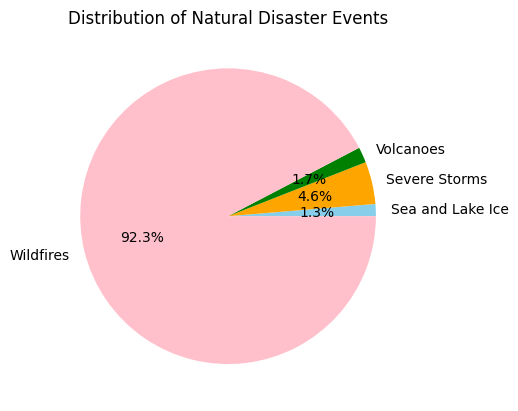

In [39]:
# The pie chart illustrates the proportion of natural disaster events in this dataset, 
# showing that Wildfires occur the most frequent, then severe storms. 
def pie_chart(nasa_df):
    pie_major = nasa_df.groupby("category").size()
    pie_major.plot(
    kind="pie",
    autopct="%1.1f%%",
    colors = ["skyblue", "orange", "green", "pink"])
    
    plt.ylabel("")
    plt.title("Distribution of Natural Disaster Events")
    plt.show()
pie_chart(nasa_df)

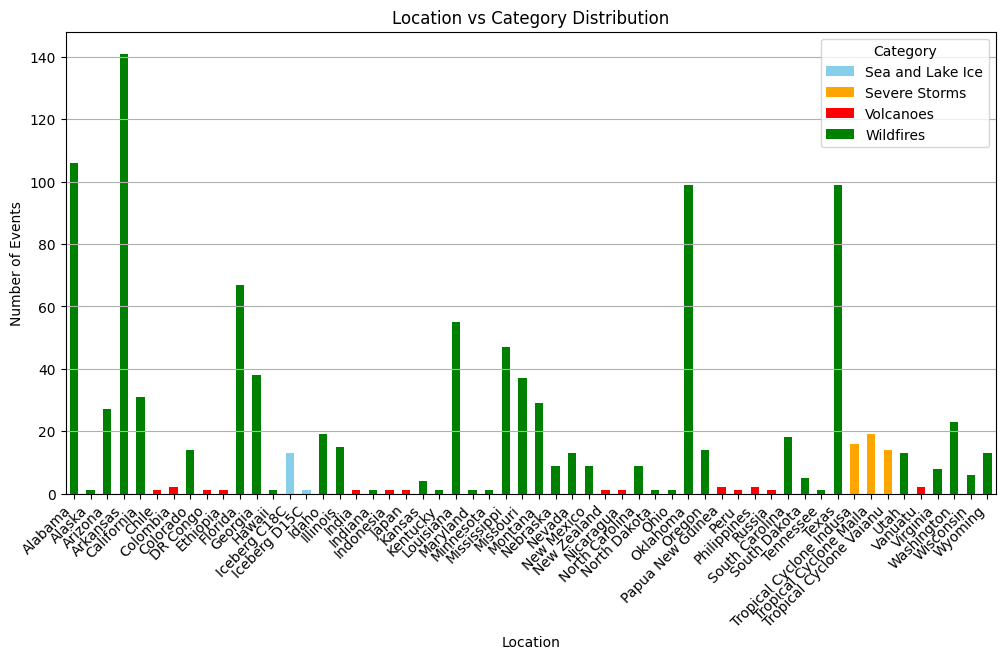

In [40]:
def locationvscategory_distribution(nasa_df, title="Location Distribution"):
    cross = pd.crosstab(nasa_df["location"], nasa_df["category"])
    cross.plot(kind="bar", stacked=True, figsize=(12,6), color =['skyblue', 'orange', 'red', 'green'])
    
    plt.xlabel("Location")
    plt.ylabel("Number of Events")
    plt.title("Location vs Category Distribution")
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Category")
    plt.grid(axis="y")
    plt.show()
locationvscategory_distribution(nasa_df)


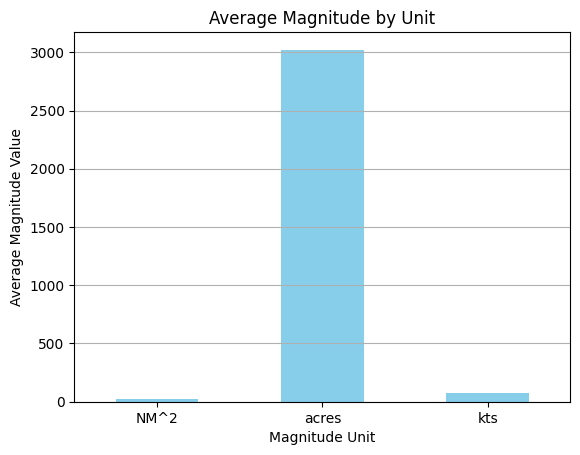

In [41]:
def bar_chart(nasa_df):
    df_plot = nasa_df.dropna(subset=["magnitude_value","magnitude_unit"])
    avg = df_plot.groupby("magnitude_unit")["magnitude_value"].mean()
    avg.plot(kind="bar", color="skyblue")

    plt.title("Average Magnitude by Unit")
    plt.xlabel("Magnitude Unit")
    plt.ylabel("Average Magnitude Value")
    plt.xticks(rotation = 0)
    plt.grid(axis="y")
    plt.show()
bar_chart(nasa_df)